In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

In [2]:
# --- IMPORTING FROM OTHER FILES
import sys
import os

# Add path to the package: relativistic_dof
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from relativistic_dof import RelativisticDOFRegistry
from maxim_distribution_analysis import AxionModelMaximDistribution

## Configure the Setup and Select the Production Channel

In this section, we choose the axion production process to analyze and set flags that control output behavior (e.g., saving plots or data). Additional parameters:

- `file_number`: We define it, to select the process:
  - $0$ : Electron scattering
  - $1$ : Muon decay
  - $2$ : Muon scattering
  - $3$ : Tau decay
  - $4$ : Tau scattering
- `data_dir`: Directory containing input data files.
- `x_decouple`: Defined as $x = \frac{m}{T}$, where:
  - $m$ : Mass of the interacting particle,
  - $T$ : Temperature of the Universe.  
  This parameter sets the decoupling moment of axions, which is assumed to be fixed in this analysis.


In [3]:
# --- SELECT FILE, SET FLAGS (MANUAL) ---
file_number = 3
flag_save_plot_comparison = False
data_dir = "data-new"
x_decouple = 30

### Load Data and Compute Results

This part of the notebook performs the core data loading and processing. Two dictionaries are created during this step:

- `our_data`: Contains the results from our own axion distribution analysis. Keys:
  - `fa`: Axion decay constant.
  - `ya`: Axion abundance.
  - `delta_neff`: Extra relativistic degrees of freedom.

- `maxim_data`: Contains reference results imported from Maxim’s simulations or calculations.  
  This includes the same physical quantities (`fa`, `delta_neff`, and `ya`), derived from external files.

The analysis proceeds through four main steps:

1. **Select filenames and titles** based on the chosen production channel.
2. **Specify particle masses** and instantiate the axion model for numerical integration.
3. **Load external ΔN_eff data** (Maxim’s results) and postprocess them.
4. **Print key diagnostics** such as number of data points and entropy-related degrees of freedom.


In [4]:
# --- Define# --- Define process labels and corresponding filenames for selected production channel ---
title_arr = [r"$\bf e$ scattering", r"$\bf \mu$ decay", r"$\bf \mu$ scattering",
             r"$\bf \tau$ decay", r"$\bf \tau$ scattering"]
filename_neff_arr = ["dNeff_fa_e_scat.dat", "dNeff_fa_mu_dec.dat", "dNeff_fa_mu_scat.dat", 
                     "dNeff_fa_tau_dec.dat", "dNeff_fa_tau_scat.dat"]
filename_dist_arr = ["Distributions_fa_e_scat.dat", "Distributions_fa_mu_dec.dat", "Distributions_fa_mu_scat.dat",
                     "Distributions_fa_tau_dec.dat", "Distributions_fa_tau_scat.dat"]
filename_save_plots_arr = ["e_scatterings", "mu_decay", "mu_scattering", "tau_decay", "tau_scattering"]
################################## WITH LOWER VALUE OF FA FOR TAON DECAYS ##########################################
expanded_data = [False, False, False, True, True]
filename_neff_expanded_arr = [None, None, None, "dNeff_fa_tau_dec_extended.dat", "dNeff_fa_tau_scat_extended.dat"]
filename_dist_expanded_arr = [None, None, None, "Distributions_fa_tau_dec_extended.dat", "Distributions_fa_tau_scat_extended.dat"]
####################################################################################################################
filename_neff = f"./{data_dir}/{filename_neff_arr[file_number]}"                    # File with fa and ΔN_eff
filename_neff_expanded = f"./{data_dir}/{filename_neff_expanded_arr[file_number]}"  # File with fa and ΔN_eff
filename_dist = f"./{data_dir}/{filename_dist_arr[file_number]}"                    # File with distribution
filename_dist_expanded = f"./{data_dir}/{filename_dist_expanded_arr[file_number]}"  # File with distribution
filename_save_plots = f"{filename_save_plots_arr[file_number]}"
flag_expanded_data = expanded_data[file_number]

In [5]:
# --- Define particle masses [in eV] ---
electron_mass = 0.511e6      # [eV]
muon_mass = 105.66e6         # [eV]
tau_mass = 1777e6            # [eV]
particle_arr = [electron_mass, muon_mass, muon_mass, tau_mass, tau_mass]

# --- Initialize axion model and extract distribution-based results ---

# Create an instance of the axion model using:
# - the selected distribution file,
# - the mass of the interacting particle,
# - the chosen decoupling point (x = m/T)
if flag_expanded_data:
    axionModel= AxionModelMaximDistribution(
        filename_dist_expanded,
        particle_arr[file_number],
        x_decouple
        )
else:
    axionModel = AxionModelMaximDistribution(
        filename_dist,
        particle_arr[file_number],
        x_decouple
    )

# Compute and retrieve ΔN_eff and axion abundance as functions of fa
our_data = axionModel.get_neff_and_ya_vs_fa()

/home/krzysztof/Workspace/Master-coding/real_distribution/maxim_distribution_analysis.py:208: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_q2, _ = quad(integrand_q2, 0, q_limit, args=i, limit=200)


In [6]:
# --- Load external ΔN_eff results from Maxim's simulation ---

# Read the reference data (fa, delta_neff) from file, skipping the header row
if flag_expanded_data:
    data = np.loadtxt(filename_neff_expanded, delimiter=",", skiprows=1)
else:
    data = np.loadtxt(filename_neff, delimiter=",", skiprows=1)

# Initialize dictionary to store processed data
maxim_data = dict()
maxim_data["fa"] = data[:, 0]                            # Axion decay constant [GeV]
maxim_data["N"] = len(data[:, 0])                        # Number of data points
maxim_data["delta_neff_nBE"] = data[:, 1]                # ΔN_eff assuming non-Bose-Einstein (nBE)
maxim_data["delta_neff_fBE"] = data[:, 2]                # ΔN_eff assuming full Bose-Einstein (fBE)

# Estimate axion abundance from ΔN_eff, formula from: 2410.18186
# ya = (ΔN_eff / 74.85)^(3/4), g_s = 43/11 (base)
# ya = (ΔN_eff / 75.64)^(3/4), g_s = 3.94  (more accurate)
maxim_data["ya_nBE"] = [(dNeff / 75.64)**(3/4) for dNeff in maxim_data["delta_neff_nBE"]]

## Sanity Check — Compare Our Results to Maxim's Data

In this section, we verify that our implementation correctly reproduces the reference results from Maxim's data files. In particular, we compare the calculated values of  $\Delta N_{\text{eff}}$ using our integration of his distribution with the original values reported in the files. This is an important consistency check to ensure that:
- We’re interpreting and integrating the distribution data correctly,
- The numerical methods are properly implemented,
- Any observed differences are physical and not due to a bug or misalignment.

We will visualize the comparison in the plot below.


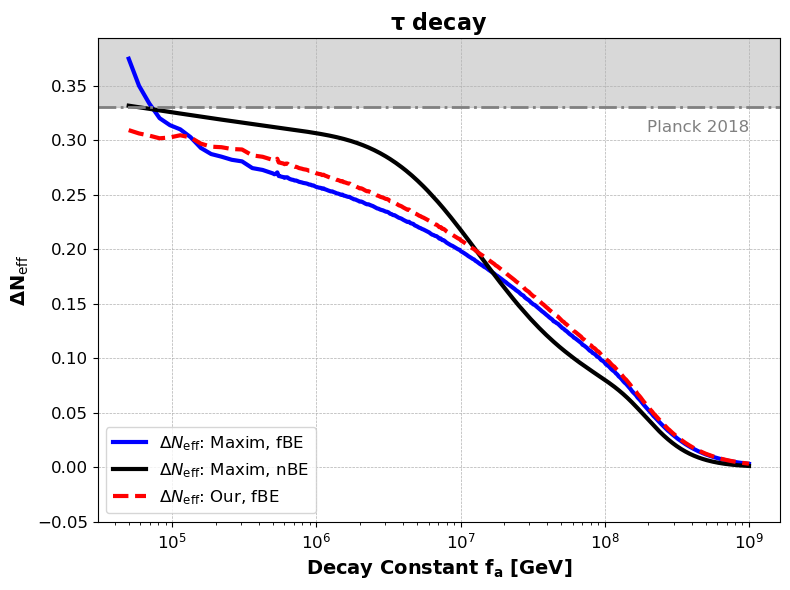

In [7]:
# --- Plot ΔN_eff: Our Results vs Maxim's Reference Data ---

fig, axs = plt.subplots(figsize=(8, 6))

# --- Plot Maxim's ΔN_eff results (fBE and nBE) ---
axs.plot(maxim_data["fa"], maxim_data["delta_neff_fBE"], color='blue', lw=3,
         label=r'$\Delta N_{\rm eff}$: Maxim, fBE')
axs.plot(maxim_data["fa"], maxim_data["delta_neff_nBE"], color='black', lw=3,
         label=r'$\Delta N_{\rm eff}$: Maxim, nBE')

# --- Plot Our ΔN_eff results (from integration using Maxim's distribution) ---
axs.plot(our_data["fa"], our_data["delta_neff"], color='red', lw=3, linestyle='--',
         label=r'$\Delta N_{\rm eff}$: Our, fBE')

# --- Axis scaling and labels ---
axs.set_xscale('log')
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{\rm eff}$', fontsize=14, fontweight='bold')
axs.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Grid and legend ---
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Planck 2018 constraint line and shaded exclusion area ---
planck_limit = 0.33
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)
axs.text(maxim_data["fa"][-1], planck_limit - 0.025, 'Planck 2018',
         color='gray', fontsize=12, va='bottom', ha='right')

# Shade region above Planck limit
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax, color='gray', alpha=0.3)

# --- Log-scale x-axis tick formatting ---
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$')
)
axs.tick_params(axis='x', which='major', labelsize=12)
axs.tick_params(axis='y', which='major', labelsize=12)

# --- Display or save the figure ---
plt.tight_layout()
plt.show()

if flag_save_plot_comparison:
    plt.savefig('Maxim_vs_Our_delta_Neff.png', format='png', dpi=300)
    plt.close()


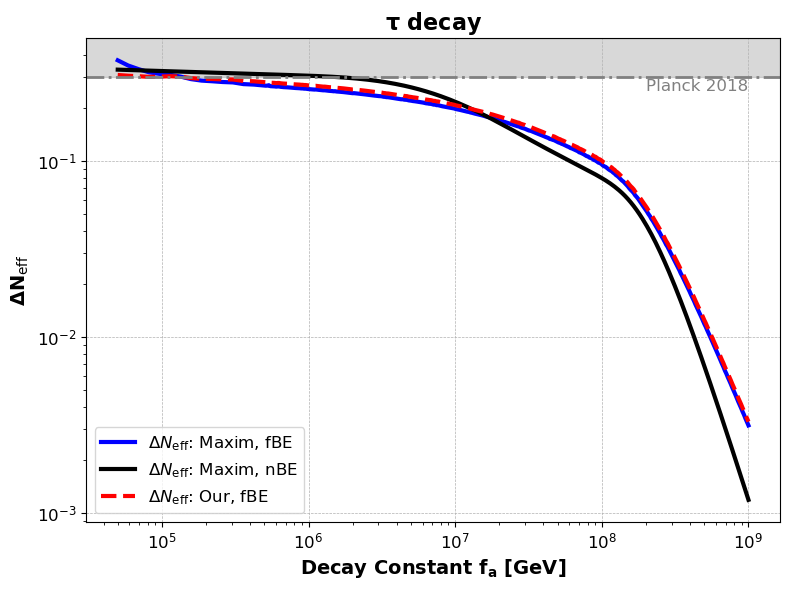

In [8]:
# --- Log-Log Plot: ΔN_eff — Our Integration vs Maxim's Data ---

fig, ax = plt.subplots(figsize=(8, 6))

# --- Plot Maxim's ΔN_eff values ---
ax.plot(maxim_data["fa"], maxim_data["delta_neff_fBE"], color='blue', lw=3,
        label=r'$\Delta N_{\rm eff}$: Maxim, fBE')
ax.plot(maxim_data["fa"], maxim_data["delta_neff_nBE"], color='black', lw=3,
        label=r'$\Delta N_{\rm eff}$: Maxim, nBE')

# --- Plot Our computed ΔN_eff from distribution integration ---
ax.plot(our_data["fa"], our_data["delta_neff"], color='red', lw=3, linestyle="--",
        label=r'$\Delta N_{\rm eff}$: Our, fBE')

# --- Set both axes to log scale ---
ax.set_xscale('log')
ax.set_yscale('log')

# --- Axis labels and plot title ---
ax.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{\rm eff}$', fontsize=14, fontweight='bold')
ax.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Grid and legend ---
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Planck 2018 constraint line and shaded region ---
planck_limit = 0.30
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text label on the constraint line
ax.text(maxim_data["fa"][-1], planck_limit * 0.8, 'Planck 2018',
        color='gray', fontsize=12, va='bottom', ha='right')

# Shade region above Planck constraint
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax, color='gray', alpha=0.3)

# --- Log-scale tick formatting on x-axis ---
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$')
)
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=12)

# --- Layout and save/display ---
plt.tight_layout()
plt.show()

if flag_save_plot_comparison:
    plt.savefig('Maxim_vs_Our_delta_Neff_loglog.png', format='png', dpi=300)
    plt.close()
